In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("sentiment_analysis_dataset.csv")

print("First 5 Reviews:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Reviews:
  Review_ID     Product        Source   Customer_ID  Rating  \
0   REV0001  Power Bank        Amazon  Customer_121       4   
1   REV0002  Power Bank        Amazon  Customer_136       4   
2   REV0003    Keyboard  Social Media  Customer_121       5   
3   REV0004      Camera        Amazon  Customer_127       5   
4   REV0005      Laptop  News Website  Customer_103       5   

                                      Review_Text Sentiment  
0  Amazing quality and very useful for daily use.  Positive  
1    The product works perfectly and looks great.  Positive  
2           Excellent product, I really loved it.  Positive  
3    The product works perfectly and looks great.  Positive  
4    Fast delivery and excellent product quality.  Positive  

Dataset Shape:
(500, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 

In [3]:
# Remove duplicate reviews
df = df.drop_duplicates()

# Remove rows where review text is missing
df = df.dropna(subset=["Review_Text"])

# Convert review text to string
df["Review_Text"] = df["Review_Text"].astype(str)

print("\nAfter Cleaning:")
print(df.shape)


After Cleaning:
(500, 7)



Sentiment Distribution:
Sentiment
Positive    257
Negative    150
Neutral      93
Name: count, dtype: int64


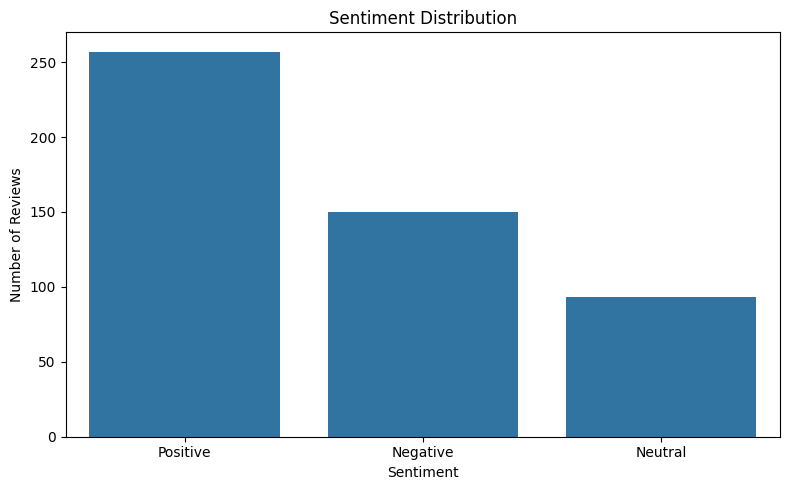

In [4]:
sentiment_count = df["Sentiment"].value_counts()

print("\nSentiment Distribution:")
print(sentiment_count)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()


In [5]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nSentiment Percentage:")
print(sentiment_percentage)



Sentiment Percentage:
Sentiment
Positive    51.4
Negative    30.0
Neutral     18.6
Name: proportion, dtype: float64


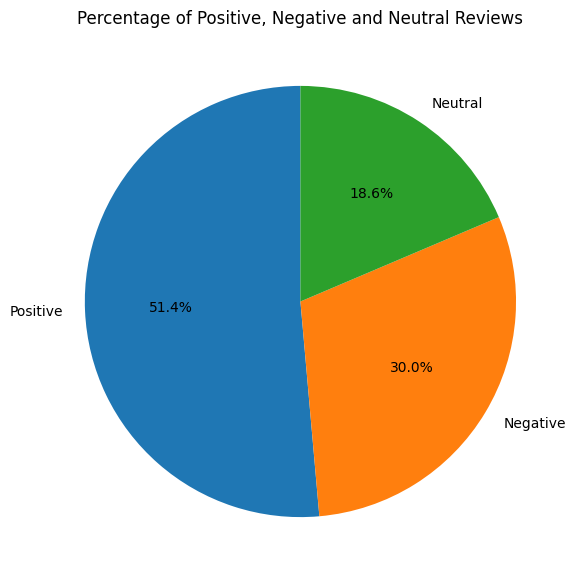

In [6]:

plt.figure(figsize=(7, 7))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Positive, Negative and Neutral Reviews")
plt.ylabel("")

plt.show()




Average Rating by Sentiment:
Sentiment
Positive    4.517510
Neutral     3.000000
Negative    1.526667
Name: Rating, dtype: float64


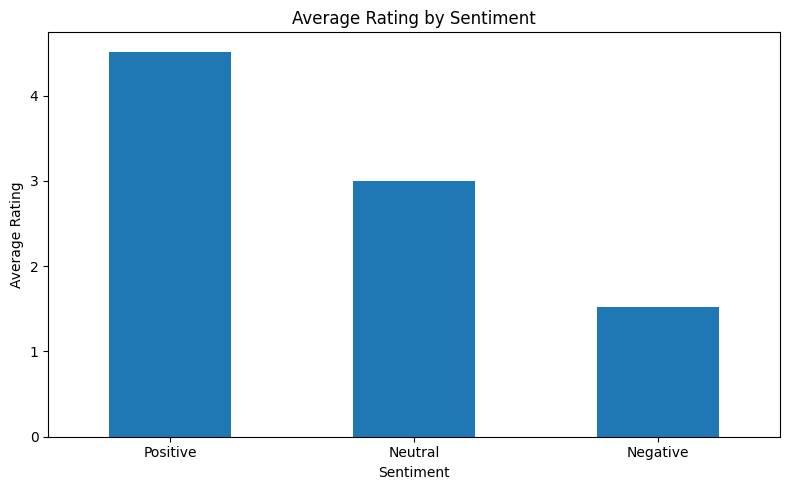

In [7]:
rating_sentiment = (
    df.groupby("Sentiment")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Rating by Sentiment:")
print(rating_sentiment)


plt.figure(figsize=(8, 5))

rating_sentiment.plot(kind="bar")

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Product-wise Sentiment:
Sentiment            Negative  Neutral  Positive
Product                                         
Bluetooth Speaker          13        8        20
Camera                     11       17        35
Keyboard                   16        9        27
Laptop                     17        7        27
Mouse                      14       10        27
Power Bank                 19       13        26
Smart Watch                16        8        25
Smartphone                 14        9        20
USB Cable                  15        9        22
Wireless Headphones        15        3        28


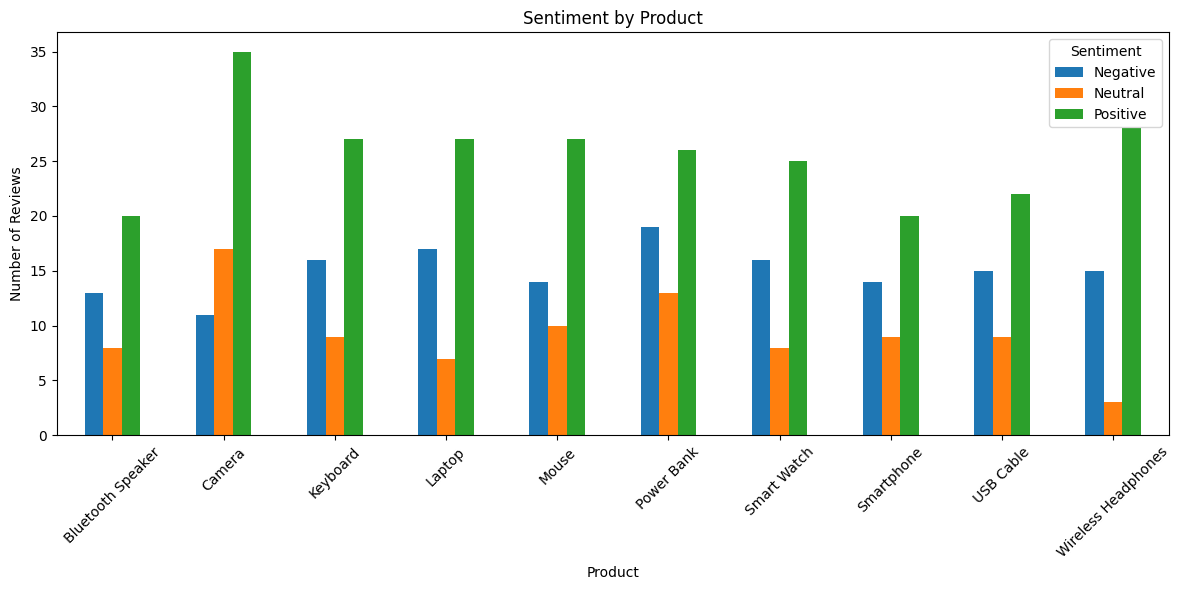

In [8]:
product_sentiment = pd.crosstab(
    df["Product"],
    df["Sentiment"]
)

print("\nProduct-wise Sentiment:")
print(product_sentiment)


product_sentiment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment by Product")
plt.xlabel("Product")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



Source-wise Sentiment:
Sentiment     Negative  Neutral  Positive
Source                                   
Amazon              43       32        91
News Website        47       24        84
Social Media        60       37        82


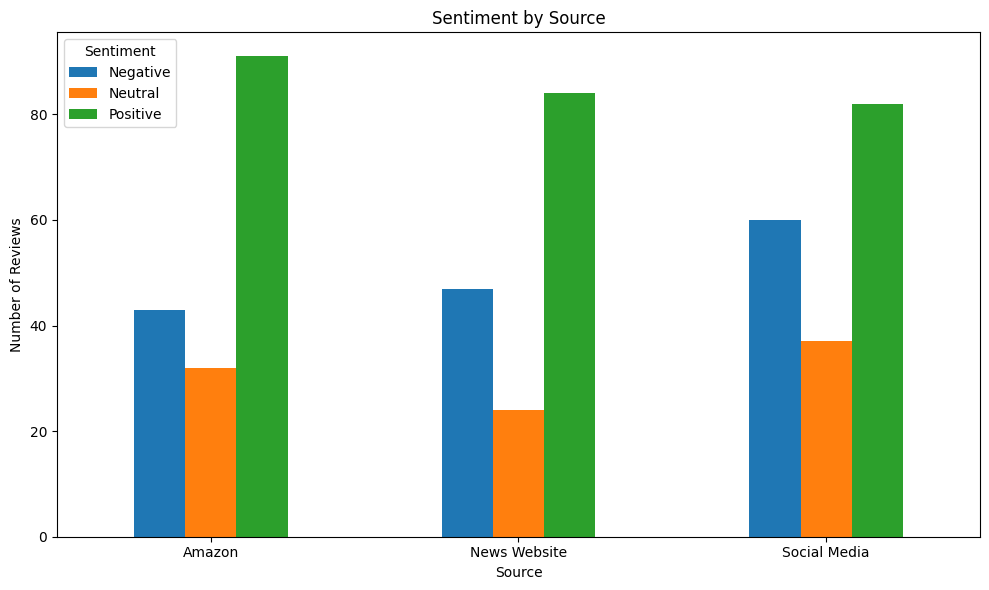

In [9]:
source_sentiment = pd.crosstab(
    df["Source"],
    df["Sentiment"]
)

print("\nSource-wise Sentiment:")
print(source_sentiment)


source_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment by Source")
plt.xlabel("Source")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

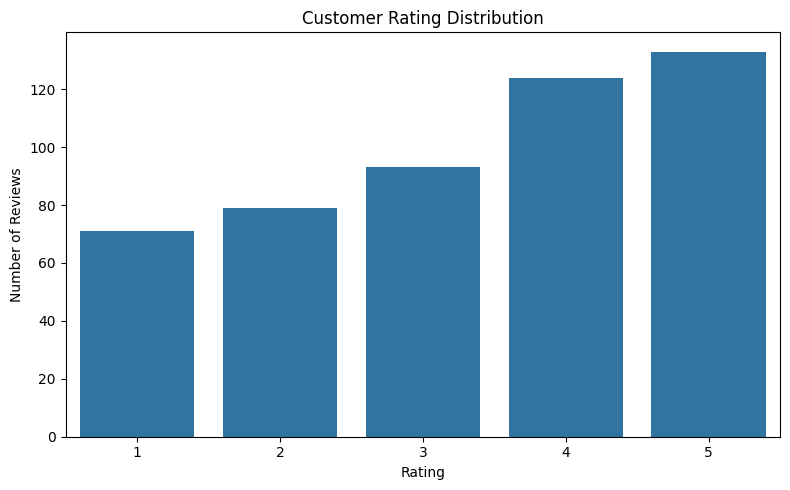

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()


In [11]:
positive_reviews = df[
    df["Sentiment"] == "Positive"
]

positive_product = (
    positive_reviews["Product"]
    .value_counts()
)

print("\nMost Positively Reviewed Products:")
print(positive_product)



Most Positively Reviewed Products:
Product
Camera                 35
Wireless Headphones    28
Mouse                  27
Keyboard               27
Laptop                 27
Power Bank             26
Smart Watch            25
USB Cable              22
Smartphone             20
Bluetooth Speaker      20
Name: count, dtype: int64


In [12]:
negative_reviews = df[
    df["Sentiment"] == "Negative"
]

negative_product = (
    negative_reviews["Product"]
    .value_counts()
)

print("\nMost Negatively Reviewed Products:")
print(negative_product)



Most Negatively Reviewed Products:
Product
Power Bank             19
Laptop                 17
Keyboard               16
Smart Watch            16
USB Cable              15
Wireless Headphones    15
Smartphone             14
Mouse                  14
Bluetooth Speaker      13
Camera                 11
Name: count, dtype: int64


In [13]:
print("\n===================================")
print("       SENTIMENT ANALYSIS SUMMARY")
print("===================================")

print("Total Reviews:", len(df))

print(
    "Positive Reviews:",
    (df["Sentiment"] == "Positive").sum()
)

print(
    "Negative Reviews:",
    (df["Sentiment"] == "Negative").sum()
)

print(
    "Neutral Reviews:",
    (df["Sentiment"] == "Neutral").sum()
)

print(
    "Average Rating:",
    round(df["Rating"].mean(), 2)
)

print("===================================")


       SENTIMENT ANALYSIS SUMMARY
Total Reviews: 500
Positive Reviews: 257
Negative Reviews: 150
Neutral Reviews: 93
Average Rating: 3.34
